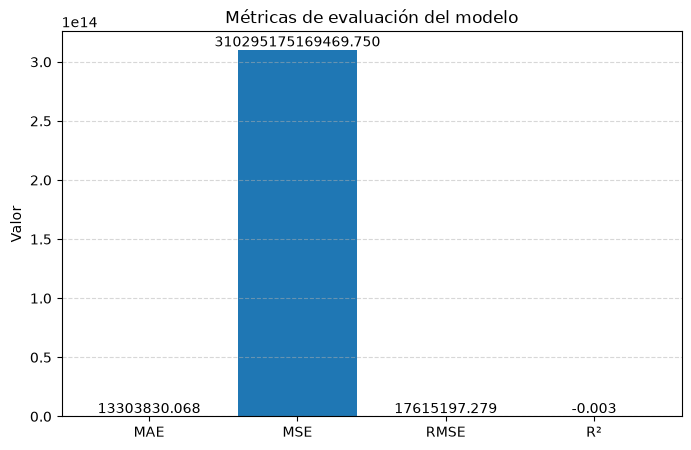

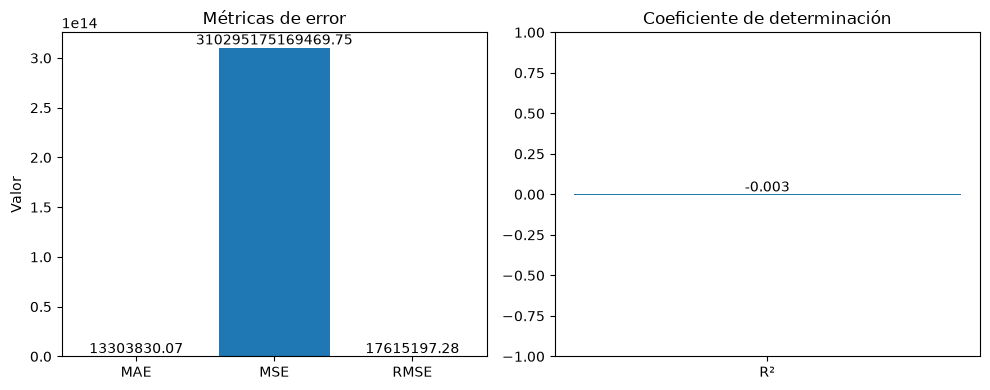

   id         price
0   1  1.715568e+07
1   2  1.715568e+07
2   3  1.715568e+07
3   4  1.715568e+07
4   5  1.715568e+07


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("data/train (1).csv")
X = df.drop(columns=['price'])
y = df['price']
X = pd.get_dummies(X, drop_first=True)

X_train,X_val,y_train,y_val = train_test_split(
    X,y, test_size=0.2, random_state=42
)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train,y_train)
y_predict = dummy.predict(X_val)
mae = mean_absolute_error(y_val, y_predict)
mse = mean_squared_error(y_val,y_predict)
rmse = mse**0.5
r2_scoring = r2_score(y_val,y_predict)

# Métricas
metricas = ['MAE', 'MSE', 'RMSE', 'R²']
valores = [mae, mse, rmse, r2_scoring]

# Crear figura
plt.figure(figsize=(8,5))
plt.bar(metricas, valores)

# Añadir etiquetas con los valores
for i, v in enumerate(valores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.title('Métricas de evaluación del modelo')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Errores
errores = ['MAE', 'MSE', 'RMSE']
valores_error = [mae, mse, rmse]

ax[0].bar(errores, valores_error)
ax[0].set_title('Métricas de error')
ax[0].set_ylabel('Valor')

for i, v in enumerate(valores_error):
    ax[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# R²
ax[1].bar(['R²'], [r2_scoring])
ax[1].set_ylim(min(-1, r2_scoring-0.1), 1)
ax[1].set_title('Coeficiente de determinación')

ax[1].text(0, r2_scoring, f'{r2_scoring:.3f}',
           ha='center', va='bottom')

plt.tight_layout()
plt.show()

#Para generar predicciones sobre el conjunto de prueba
test = pd.read_csv('data/test (1).csv')
X_test = pd.get_dummies(test, drop_first=True)
X_test = X_test.reindex(columns=X.columns, fill_value=0)
predictions = dummy.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'price': predictions
    })

submission.to_csv('submission_dummy_levi.csv', index=False)

print(submission.head())